In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt

from neural_capm.data.loaders import load_price_series, compute_returns
from neural_capm.data.preprocessing import build_macro_feature_matrix

In [2]:
reliance_prices = load_price_series("RELIANCE.NS")
reliance_ret = compute_returns(reliance_prices)

daily_dates = reliance_ret.index
print(daily_dates.min(), daily_dates.max(), len(daily_dates))

2015-01-02 00:00:00 2024-12-30 00:00:00 2465


In [3]:
macro_features = build_macro_feature_matrix(daily_dates)
print(macro_features.shape)
macro_features.head(10)

(2465, 2)


,india_cpi,india_10y_yield
Date,,
2015-01-02,96.78036,7.79366
2015-01-05,96.78036,7.79366
2015-01-06,96.78036,7.79366
2015-01-07,96.78036,7.79366
2015-01-08,96.78036,7.79366
2015-01-09,96.78036,7.79366
2015-01-12,96.78036,7.79366
2015-01-13,96.78036,7.79366
2015-01-14,96.78036,7.79366


In [4]:
print(macro_features.isna().sum())

india_cpi          0
india_10y_yield    0
dtype: int64


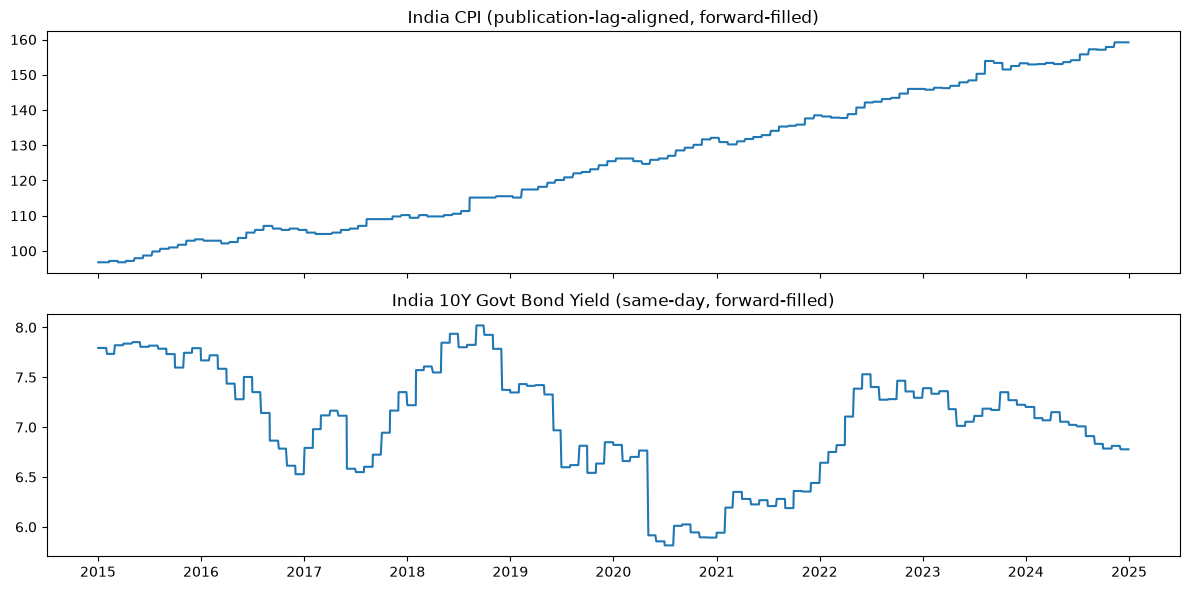

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(macro_features.index, macro_features["india_cpi"])
axes[0].set_title("India CPI (publication-lag-aligned, forward-filled)")
axes[1].plot(macro_features.index, macro_features["india_10y_yield"])
axes[1].set_title("India 10Y Govt Bond Yield (same-day, forward-filled)")
plt.tight_layout()
plt.show()

In [6]:
print(macro_features.isna().sum())

india_cpi          0
india_10y_yield    0
dtype: int64
